**Sub questions:**
- **(a)** Using NumPy, compute a **normalized 5×5 Gaussian kernel** for σ = 2
- **(b)** Visualize a **51×51 Gaussian kernel** as a **3D surface plot**
- **(c)** Apply Gaussian smoothing using the **manually computed kernel**
- **(d)** Do the same using **OpenCV's `cv.GaussianBlur()`** and compare

**Image:** `rice.png`

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import os

# Load grayscale image
img = cv.imread('../images/rice.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "Could not load rice.png"

print(f"Image : rice.png")
print(f"Shape : {img.shape}")
print(f"Dtype : {img.dtype}")
print(f"Mean  : {img.mean():.2f} | Std: {img.std():.2f}")

os.makedirs('../outputs/q5', exist_ok=True)


Image : rice.png
Shape : (256, 256)
Dtype : uint8
Mean  : 111.25 | Std: 42.49


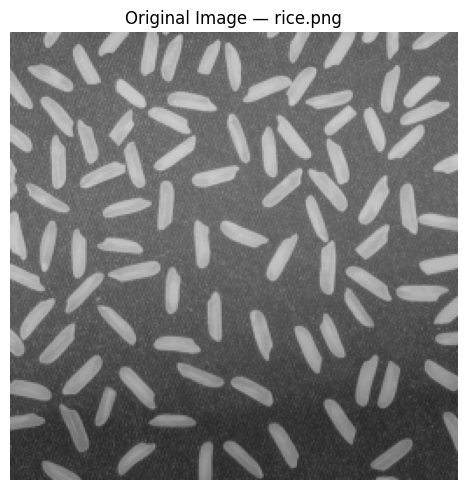

In [2]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img, cmap='gray', vmin=0, vmax=255)
ax.set_title('Original Image — rice.png', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('../outputs/q5/q5_original.png', dpi=150, bbox_inches='tight')
plt.show()


## (a) Normalized 5×5 Gaussian Kernel, σ = 2

In [3]:
def gaussian_kernel_2d(size, sigma):
    assert size % 2 == 1, "Kernel size must be odd"

    half = size // 2                          # e.g. 2 for a 5x5 kernel
    ax   = np.arange(-half, half + 1)         # [-2, -1, 0, 1, 2]

    # Create 2D coordinate grids
    X, Y = np.meshgrid(ax, ax)               # both shape (size, size)

    # Evaluate Gaussian (without the 1/2pi*sigma^2 prefactor)
    kernel_raw = np.exp(-(X**2 + Y**2) / (2.0 * sigma**2))

    # Normalize so the kernel sums to 1
    kernel = kernel_raw / kernel_raw.sum()

    return kernel


# Compute the 5x5 kernel for sigma = 2
sigma  = 2
kernel_5x5 = gaussian_kernel_2d(size=5, sigma=sigma)

print(f"5×5 Gaussian Kernel (σ = {sigma}):")
print(f"Sum of all values: {kernel_5x5.sum():.10f}  (should be 1.0)")
print()
print(np.round(kernel_5x5, 6))


5×5 Gaussian Kernel (σ = 2):
Sum of all values: 1.0000000000  (should be 1.0)

[[0.023247 0.033824 0.038328 0.033824 0.023247]
 [0.033824 0.049214 0.055766 0.049214 0.033824]
 [0.038328 0.055766 0.063191 0.055766 0.038328]
 [0.033824 0.049214 0.055766 0.049214 0.033824]
 [0.023247 0.033824 0.038328 0.033824 0.023247]]


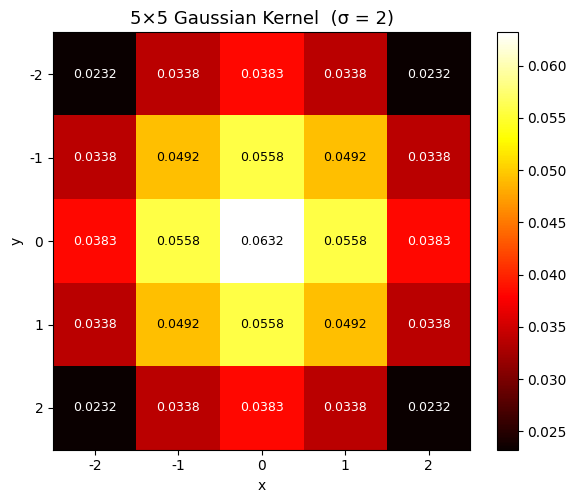

In [4]:
# Visualize 5x5 kernel as a heatmap with values annotated
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(kernel_5x5, cmap='hot', interpolation='nearest')
plt.colorbar(im, ax=ax)

# Annotate each cell with its value
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{kernel_5x5[i, j]:.4f}',
                ha='center', va='center', fontsize=9,
                color='black' if kernel_5x5[i, j] > 0.04 else 'white')

ax.set_title(f'5×5 Gaussian Kernel  (σ = {sigma})', fontsize=13)
ax.set_xticks(range(5)); ax.set_xticklabels(['-2','-1','0','1','2'])
ax.set_yticks(range(5)); ax.set_yticklabels(['-2','-1','0','1','2'])
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.savefig('../outputs/q5/q5_kernel_5x5_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## (b) 51×51 Gaussian Kernel — 3D Surface Plot

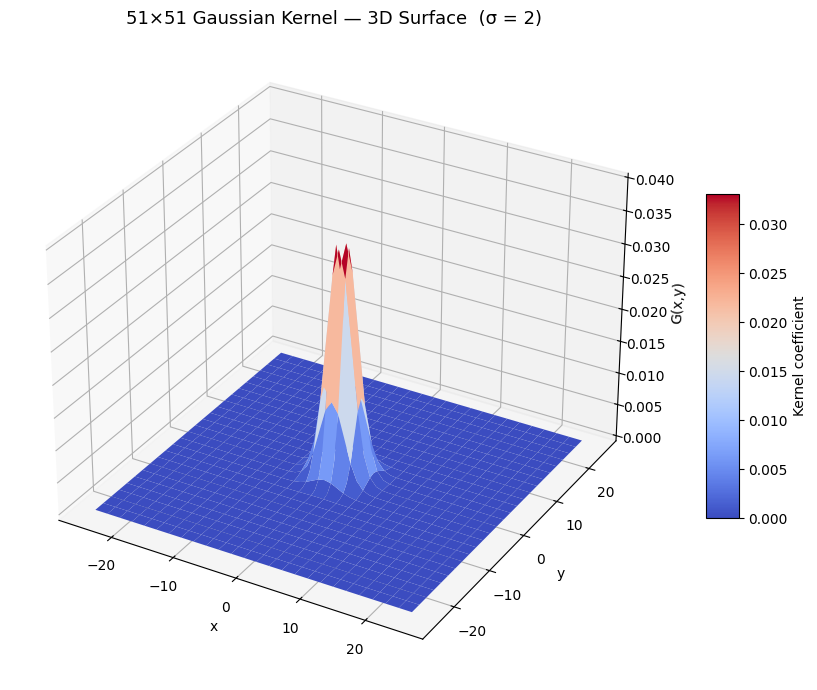

51×51 kernel — Max value (centre): 0.03978874
Sum of all values                : 1.0000000000


In [5]:
# Compute 51x51 Gaussian kernel
kernel_51x51 = gaussian_kernel_2d(size=51, sigma=sigma)

# Build coordinate axes for the surface plot
half_51 = 25
ax_coords = np.arange(-half_51, half_51 + 1)   # -25 to 25
X51, Y51  = np.meshgrid(ax_coords, ax_coords)

# 3D surface plot
fig = plt.figure(figsize=(10, 7))
ax3d = fig.add_subplot(111, projection='3d')

surf = ax3d.plot_surface(X51, Y51, kernel_51x51,
                          cmap=cm.coolwarm,
                          linewidth=0,
                          antialiased=True)

fig.colorbar(surf, ax=ax3d, shrink=0.5, aspect=10, label='Kernel coefficient')

ax3d.set_title(f'51×51 Gaussian Kernel — 3D Surface  (σ = {sigma})', fontsize=13)
ax3d.set_xlabel('x'); ax3d.set_ylabel('y'); ax3d.set_zlabel('G(x,y)')
ax3d.view_init(elev=30, azim=-60)

plt.tight_layout()
plt.savefig('../outputs/q5/q5_kernel_51x51_3d.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"51×51 kernel — Max value (centre): {kernel_51x51.max():.8f}")
print(f"Sum of all values                : {kernel_51x51.sum():.10f}")


## (c) Gaussian Smoothing with Manual Kernel

In [6]:
# Apply 5x5 Gaussian kernel manually using cv.filter2D
kernel_f32  = kernel_5x5.astype(np.float32)
img_manual  = cv.filter2D(img, ddepth=-1, kernel=kernel_f32)

print(f"Original  — Mean: {img.mean():.2f} | Std: {img.std():.2f}")
print(f"Smoothed  — Mean: {img_manual.mean():.2f} | Std: {img_manual.std():.2f}")
print()
print("Note: mean is preserved (kernel sums to 1), std decreases (smoothing reduces contrast)")


Original  — Mean: 111.25 | Std: 42.49
Smoothed  — Mean: 111.24 | Std: 38.39

Note: mean is preserved (kernel sums to 1), std decreases (smoothing reduces contrast)


## (d) Gaussian Smoothing with OpenCV `cv.GaussianBlur()`

In [7]:
# Apply OpenCV GaussianBlur with same parameters
img_opencv = cv.GaussianBlur(img, ksize=(5, 5), sigmaX=sigma)

# Pixel-wise difference
diff       = cv.absdiff(img_manual, img_opencv)
max_diff   = int(diff.max())
mean_diff  = diff.mean()

print(f"OpenCV GaussianBlur — Mean: {img_opencv.mean():.2f} | Std: {img_opencv.std():.2f}")
print()
print(f"Pixel-wise comparison — Manual vs OpenCV:")
print(f"  Max  difference : {max_diff}")
print(f"  Mean difference : {mean_diff:.4f}")
print()
if max_diff <= 2:
    print("✓ Results are consistent — small differences due to kernel generation method")
else:
    print("✗ Larger differences observed — investigate kernel generation")


OpenCV GaussianBlur — Mean: 111.24 | Std: 38.39

Pixel-wise comparison — Manual vs OpenCV:
  Max  difference : 1
  Mean difference : 0.0069

✓ Results are consistent — small differences due to kernel generation method


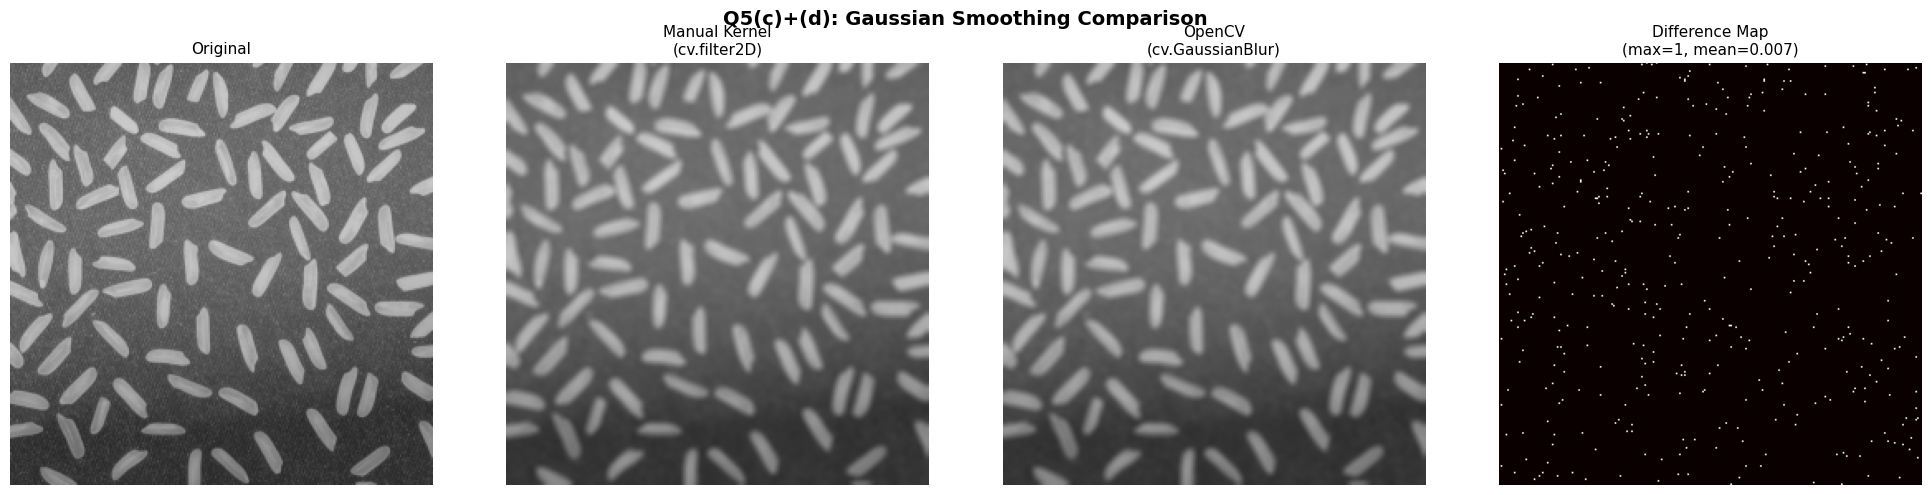

In [8]:
# Visual comparison: original | manual | OpenCV | difference
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Q5(c)+(d): Gaussian Smoothing Comparison', fontsize=14, fontweight='bold')

axes[0].imshow(img,        cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original', fontsize=11); axes[0].axis('off')

axes[1].imshow(img_manual, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Manual Kernel\n(cv.filter2D)', fontsize=11); axes[1].axis('off')

axes[2].imshow(img_opencv, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('OpenCV\n(cv.GaussianBlur)', fontsize=11); axes[2].axis('off')

axes[3].imshow(diff, cmap='hot')
axes[3].set_title(f'Difference Map\n(max={max_diff}, mean={mean_diff:.3f})', fontsize=11)
axes[3].axis('off')

plt.tight_layout()
plt.savefig('../outputs/q5/q5_gaussian_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


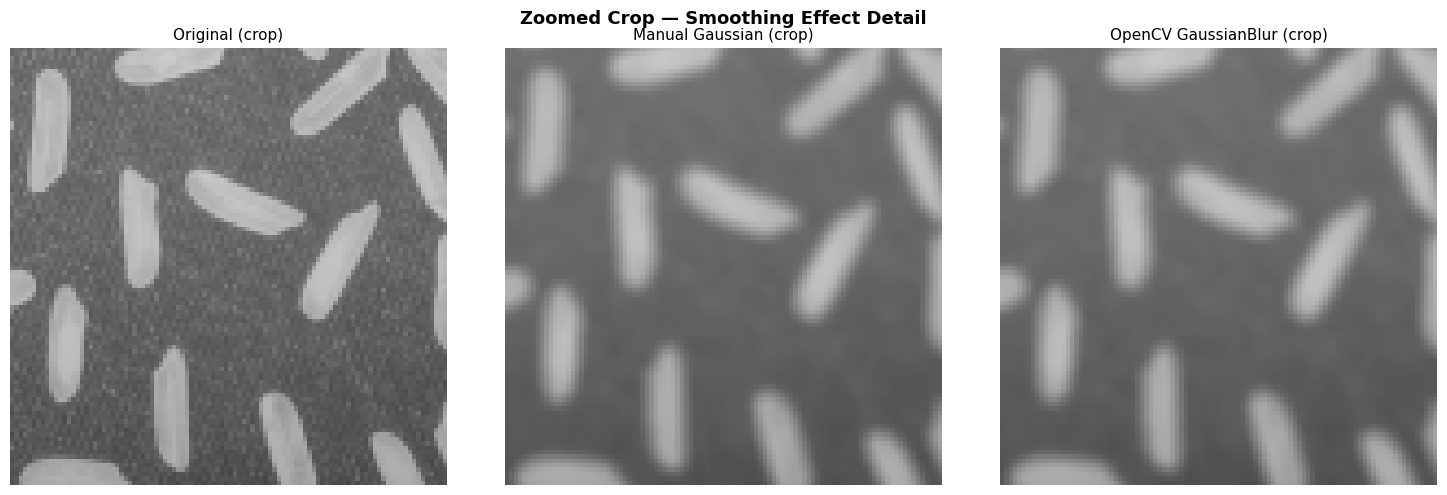

In [9]:
# Zoomed-in crop to show smoothing effect more clearly
r1, r2, c1, c2 = 80, 180, 80, 180   # crop region

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Zoomed Crop — Smoothing Effect Detail', fontsize=13, fontweight='bold')

axes[0].imshow(img[r1:r2, c1:c2],        cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original (crop)', fontsize=11); axes[0].axis('off')

axes[1].imshow(img_manual[r1:r2, c1:c2], cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Manual Gaussian (crop)', fontsize=11); axes[1].axis('off')

axes[2].imshow(img_opencv[r1:r2, c1:c2], cmap='gray', vmin=0, vmax=255)
axes[2].set_title('OpenCV GaussianBlur (crop)', fontsize=11); axes[2].axis('off')

plt.tight_layout()
plt.savefig('../outputs/q5/q5_zoom_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# Summary statistics
print(f"{'Image':<30} {'Mean':>8} {'Std':>8} {'Min':>6} {'Max':>6}")
print("-" * 65)
for name, image in [('Original',              img),
                    ('Manual Gaussian (5x5)',  img_manual),
                    ('OpenCV GaussianBlur',    img_opencv)]:
    print(f"{name:<30} {image.mean():>8.2f} {image.std():>8.2f} "
          f"{int(image.min()):>6} {int(image.max()):>6}")
print()
print(f"Max pixel difference (manual vs OpenCV): {max_diff}")


Image                              Mean      Std    Min    Max
-----------------------------------------------------------------
Original                         111.25    42.49     40    204
Manual Gaussian (5x5)            111.24    38.39     46    202
OpenCV GaussianBlur              111.24    38.39     46    202

Max pixel difference (manual vs OpenCV): 1
